# Model 2: Random Forest

In this model, we build on the baseline model.

The baseline used price-related features only.

Here, we extend the model by adding duration, which is part of the research question.

This allows us to test if duration improves the model performance.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
# Load datasets
df_udemy = pd.read_csv("udemy_courses_dataset (1).csv")
df_shaguf = pd.read_csv("shaguf_cleaned_final (1).csv")

In [31]:
# Prepare Udemy
df_udemy = df_udemy[[
    "course_title",
    "content_duration",
    "price",
    "num_subscribers"
]]

df_udemy = df_udemy.rename(columns={
    "course_title": "title",
    "content_duration": "duration",
    "num_subscribers": "students"
})

We prepare Udemy data and include duration.

In [32]:
# Prepare Shaguf
df_shaguf = df_shaguf[[
    "title",
    "duration_clean_normalized",
    "price_clean",
    "students_capped",
    "has_discount_clean",
    "is_free"
]]

df_shaguf = df_shaguf.rename(columns={
    "duration_clean_normalized": "duration",
    "price_clean": "price",
    "students_capped": "students",
    "has_discount_clean": "has_discount"
})

We prepare Shaguf.

In [33]:
# Combine datasets
df = pd.concat([df_udemy, df_shaguf], ignore_index=True)

In [34]:
# Clean data
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["price"] = df["price"].fillna(df["price"].median())

df["students"] = pd.to_numeric(df["students"], errors="coerce")
df["students"] = df["students"].fillna(df["students"].median())

df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df["duration"] = df["duration"].fillna(df["duration"].median())

We clean the duration values and fill missing data.

In [35]:
# Transformations
df["price_log"] = np.log1p(df["price"])
df["students_log"] = np.log1p(df["students"])

df["has_discount"] = df["has_discount"].fillna(False)
df["is_free"] = df["price"] == 0

/tmp/ipykernel_15931/3541921526.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["has_discount"] = df["has_discount"].fillna(False)


We create features for modeling.

In [37]:
# Features
X = df[[
    "price_log",
    "is_free",
    "has_discount",
    "duration"
]]

y = df["students_log"]

We include duration in the model features.

In [38]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

We split the data into training and testing sets.

In [39]:
# Model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, n_estimators=200, random_state=42)

We train the Random Forest model.

In [40]:
# Prediction
y_pred = model.predict(X_test)

In [43]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 1.79131926733798
RMSE = 2.217945290252806
R² = 0.482713637133514


## Results

MAE = 1.79  
RMSE = 2.21  
R² = 0.48  

The model explains around 48% of the variation in student enrollment.

This shows a noticeable improvement compared to the baseline model.

Adding duration helped the model capture more patterns in the data, while keeping the structure consistent with the baseline.

## Visualization 1: Actual vs Predicted

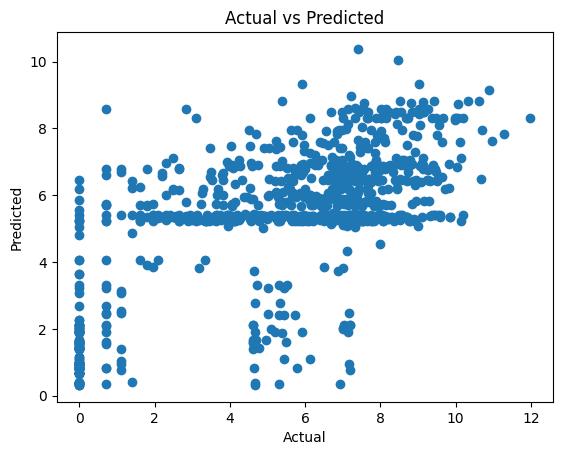

In [44]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

From the plot, we can see that the points are somewhat scattered and not forming a clear straight line.

There is a concentration of predictions around the middle values, while the actual values are more spread out.

This means the model is capturing some patterns, but it is not very precise for all cases.

## Visualization 2: Feature Importance

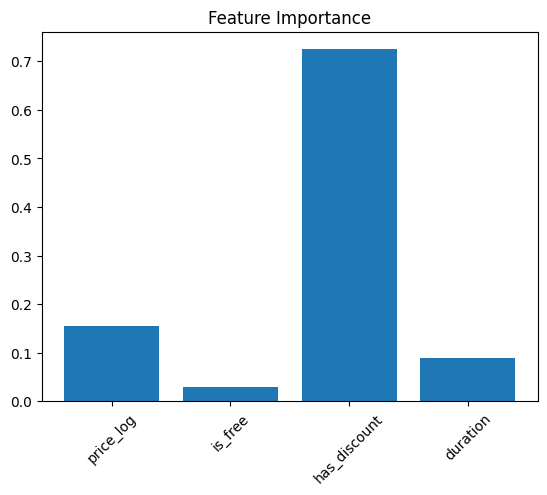

In [45]:
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

From the plot, we can see that "has_discount" has the highest importance in the model.

Price also has some effect, while duration has a moderate impact.

"is_free" has very low importance compared to the other features.

This shows that the model relies more on discount information when making predictions.

## Visualization 3: Residual Plot

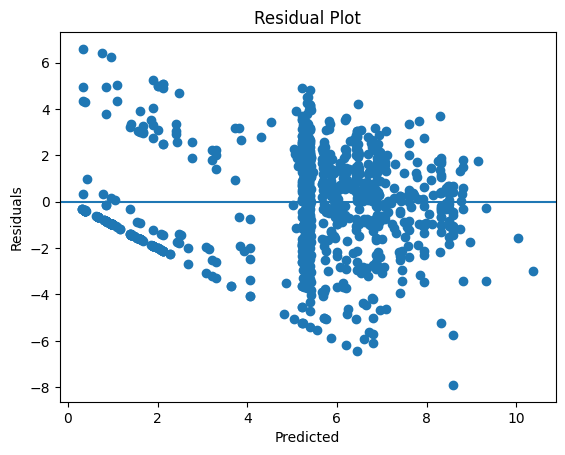

In [46]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

From the plot, the residuals are spread around zero, but not completely random.

There are some visible patterns and clusters, especially in the middle range.

This suggests that the model still has some systematic errors and does not fully capture all relationships in the data.

## Conclusion

The model shows good performance and explains part of the data.

Adding duration helped improve the model and made it more aligned with the research question.

Discount had the strongest effect, while price and duration also played a role.

The model still has some errors, but it gives useful insights.